# Feature Maps and Nonlinear Classification

This demo follows the first part of Lecture 6: transform the data, then apply an ordinary linear classifier in the transformed space.

## 1. A dataset that is not linearly separable

We use $x=-1,0,1$ with labels $+1,-1,+1$. A threshold of a linear function of $x$ cannot separate these examples.

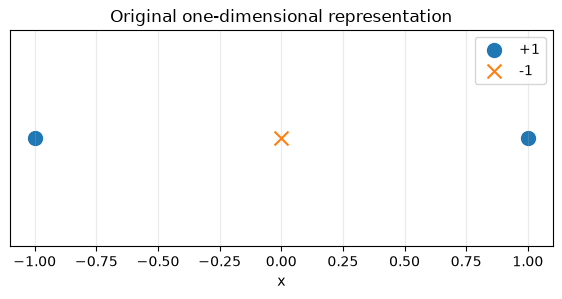

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-1.0, 0.0, 1.0])
y = np.array([1, -1, 1])

plt.figure(figsize=(7, 2.8))
plt.scatter(x[y == 1], np.zeros(np.sum(y == 1)), marker='o', s=100, label='+1')
plt.scatter(x[y == -1], np.zeros(np.sum(y == -1)), marker='x', s=100, label='-1')
plt.yticks([])
plt.xlabel('x')
plt.title('Original one-dimensional representation')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 2. Apply the feature map

Use

$$\phi(x) = (x, x^2).$$

The classifier remains linear in $\phi(x)$, but the resulting decision function is quadratic in the original $x$.

In [2]:
def phi(x):
    return np.column_stack([x, x**2])

X_phi = phi(x)
print(X_phi)

[[-1.  1.]
 [ 0.  0.]
 [ 1.  1.]]


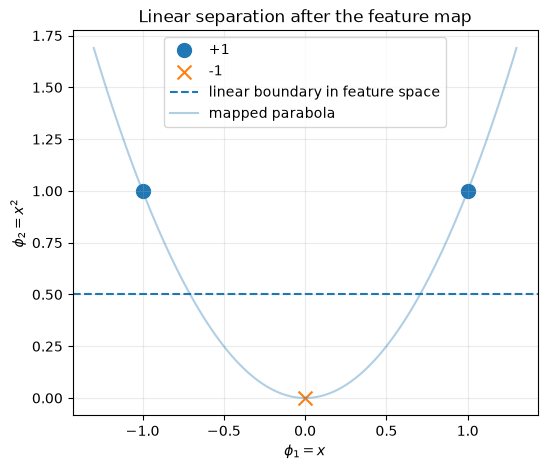

Predictions: [ 1 -1  1]


In [3]:
theta = np.array([0.0, 1.0])
scores = X_phi @ theta
predictions = np.where(scores >= 0.5, 1, -1)

plt.figure(figsize=(6, 5))
plt.scatter(X_phi[y == 1, 0], X_phi[y == 1, 1], s=100, label='+1')
plt.scatter(X_phi[y == -1, 0], X_phi[y == -1, 1], marker='x', s=100, label='-1')

u = np.linspace(-1.3, 1.3, 200)
plt.axhline(0.5, linestyle='--', label='linear boundary in feature space')
plt.plot(u, u**2, alpha=0.35, label='mapped parabola')
plt.xlabel(r'$\phi_1=x$')
plt.ylabel(r'$\phi_2=x^2$')
plt.title('Linear separation after the feature map')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print('Predictions:', predictions)

## 3. Back in the original space

With $\theta=(0,1)$ and threshold $0.5$, the decision rule is equivalent to thresholding $x^2$:

$$x^2 \ge 0.5.$$

So a **linear** boundary in feature space corresponds to a **nonlinear** decision rule in the original space.

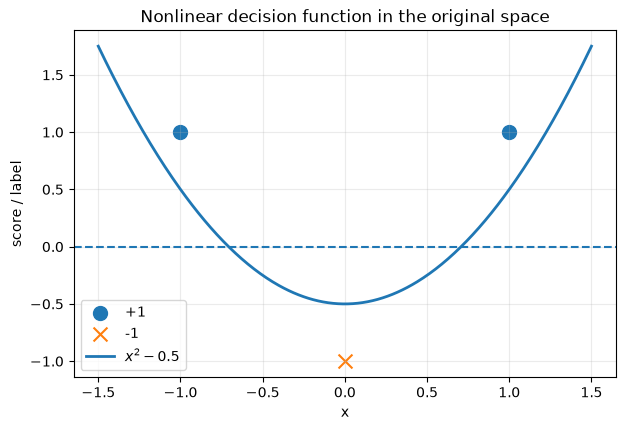

In [4]:
grid = np.linspace(-1.5, 1.5, 400)
score = grid**2 - 0.5

plt.figure(figsize=(7, 4.5))
plt.scatter(x[y == 1], y[y == 1], s=100, label='+1')
plt.scatter(x[y == -1], y[y == -1], marker='x', s=100, label='-1')
plt.plot(grid, score, linewidth=2, label=r'$x^2-0.5$')
plt.axhline(0, linestyle='--')
plt.xlabel('x')
plt.ylabel('score / label')
plt.title('Nonlinear decision function in the original space')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Takeaway

The learning algorithm did not need to become nonlinear. We changed the representation. The same linear machinery can now operate in the expanded feature space.